# Kubernetes Concepts for Scaling ML Deployments

Picture your model API packaged as a *container* — a self-contained, runnable box holding the app and everything it needs (the bridge below defines this precisely; Unit 4 teaches you to build one yourself). Traffic spikes — your one container can't keep up. Kubernetes (K8s) orchestrates multiple replicas of your container, routes traffic between them, and automatically scales up or down based on load.

**Note:** `kubectl` runs against a live cluster and can't execute inside a Jupyter kernel. This notebook teaches K8s concepts through YAML examples and explains each command's effect. Run the commands in a terminal connected to a K8s cluster (Minikube, Kind, or cloud).

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 01 "01. Big Data Concepts & Distributed Computing Theory" — scale-out, work distribution and fault tolerance across machines; Kubernetes applies those same ideas to replicas of your model API instead of partitions of a dataset.


## 📰 The day autoscaling could not save anyone: AWS us-east-1, October 2025

At **11:48 PM PDT on 19 October 2025**, a latent race condition in DynamoDB's automated DNS management left the service's regional endpoint pointing at an **empty DNS record** in AWS's `us-east-1` region. Two DNS automation processes ran concurrently, a stale plan overwrote a newer one, and cleanup automation then deleted it. DNS was restored by **2:25 AM** — under three hours — but the damage had propagated: EC2's instance-launch subsystem entered what AWS described as **congestive collapse**, and **new instances could not be launched** while it recovered. AWS puts the whole event from **11:48 PM PDT on 19 October to 2:20 PM PDT on 20 October — about 14 and a half hours** — across dozens of services.

Read that through the lens of this notebook. A HorizontalPodAutoscaler responds to load by asking for more Pods. More Pods need nodes. Nodes need instances. **When the cloud cannot launch instances, "scale up" is a request that nobody answers** — and your carefully tuned `maxReplicas: 10` becomes a number in a YAML file.

**What goes wrong without this lesson.** One container on one machine has no answer to any of the questions production asks: who restarts it at 3 a.m., who adds capacity when traffic triples, who keeps traffic away from a Pod that is still loading a 500 MB model, and how a new version reaches users without a gap. Kubernetes answers all four declaratively — and it does so within limits that the outage above draws very clearly.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain what a Pod, Deployment, Service, and HPA are in plain terms
2. Read and write a Deployment YAML for an ML model container
3. Understand how a LoadBalancer Service routes traffic to Pods
4. Configure an HPA that scales 2-10 replicas based on CPU utilization
5. Explain zero-downtime rolling updates

## Containers in 60 Seconds (bridge — Docker is taught fully in Unit 4)

Kubernetes orchestrates *containers*, and this course teaches Docker itself in Unit 4 — two notebooks from now in the numbered path. You only need three definitions to follow everything below:

- **Image** — a frozen snapshot of an application plus everything it needs to run: OS libraries, Python, packages, your code, your model file. Named with a tag like `iris-classifier:v2` (`name:version`).
- **Container** — a *running instance* of an image. One image can be started as many identical containers — which is exactly what "scaling to 5 replicas" means.
- **Registry** — the store images are pushed to and pulled from (like PyPI, but for images). A cluster node pulls the image by name before starting a container from it.

That's the whole substrate: Kubernetes takes an image *name*, pulls it from a registry, and keeps N containers of it running. When a manifest below says `image: iris-classifier:v2`, read it as "run this frozen app snapshot". How to *build* such an image (Dockerfile, `docker build`, `docker run`) is Unit 4, notebook 01.

## 1. The Problem Kubernetes Solves

Plain Docker: you run one container. If it crashes, it's gone. If traffic doubles, you manually start another. You have to load-balance them yourself.

Kubernetes:
- Keeps your desired number of replicas running at all times (if one crashes, K8s starts a replacement)
- Routes incoming traffic across all healthy replicas
- Watches CPU/memory usage and adds or removes replicas automatically
- Deploys new versions without any downtime

## 2. Key Concepts

**Pod** — the smallest K8s unit. Usually wraps one container. If a Pod crashes, K8s schedules a new one. Pods are ephemeral: don't store state in them.

**Deployment** — declares *how many* Pods to run and *which container image* to use. The Deployment controller continuously reconciles reality with the declaration.

**Service** — a stable network address (IP + DNS name) that routes traffic to a set of Pods. Pods come and go; the Service IP stays fixed.

**HorizontalPodAutoscaler (HPA)** — watches CPU (or custom metrics) and adjusts the Deployment's replica count automatically.

In [1]:
# WHAT: create a working folder for the Kubernetes manifests we are about to write.
# WHY: K8s is configured declaratively through YAML files — this lesson builds
# them one by one so each concept (Deployment, Service, HPA) stays separate.
import os

YAML_DIR = "/tmp/k8s_manifests"
os.makedirs(YAML_DIR, exist_ok=True)
print(f"Writing K8s manifests to {YAML_DIR}")

Writing K8s manifests to /tmp/k8s_manifests


## 3. The Deployment YAML

A Deployment YAML is a declarative description of what you want to run. K8s continuously works to make the cluster match this declaration.

In [2]:
# WHAT: write the Deployment manifest — 3 replicas of the model-serving container.
# WHY: the Deployment is where availability policy lives: replica count, rolling-
# update rules, resource requests/limits, and the readiness/liveness probes.
# The manifest is stored as a Python string; the inline # notes inside the
# YAML explain what each field controls — read them top to bottom.
deployment_yaml = """\
apiVersion: apps/v1
kind: Deployment
metadata:
  name: iris-classifier
  labels:
    app: iris-classifier
spec:
  replicas: 3                          # Run 3 Pods simultaneously
  selector:
    matchLabels:
      app: iris-classifier             # This Deployment manages Pods with this label
  strategy:
    type: RollingUpdate
    rollingUpdate:
      maxSurge: 1                      # Allow 1 extra Pod during an update
      maxUnavailable: 0                # Never take a Pod down before a new one is ready
  template:
    metadata:
      labels:
        app: iris-classifier
    spec:
      containers:
        - name: iris-classifier
          image: myregistry/iris-classifier:v2   # Docker image to run
          ports:
            - containerPort: 8000
          resources:
            requests:
              cpu: "250m"              # 0.25 CPU cores requested (used for scheduling)
              memory: "256Mi"
            limits:
              cpu: "500m"              # Hard cap: container cannot use more than 0.5 cores
              memory: "512Mi"
          readinessProbe:              # K8s won't send traffic until this passes
            httpGet:
              path: /health
              port: 8000
            initialDelaySeconds: 10
            periodSeconds: 5
          livenessProbe:               # K8s restarts the container if this fails
            httpGet:
              path: /health
              port: 8000
            initialDelaySeconds: 30
            periodSeconds: 10
"""

# Save the manifest; in a real cluster you would `kubectl apply -f` this file.
with open(f"{YAML_DIR}/deployment.yaml", "w") as f:
    f.write(deployment_yaml)

print(deployment_yaml)

apiVersion: apps/v1
kind: Deployment
metadata:
  name: iris-classifier
  labels:
    app: iris-classifier
spec:
  replicas: 3                          # Run 3 Pods simultaneously
  selector:
    matchLabels:
      app: iris-classifier             # This Deployment manages Pods with this label
  strategy:
    type: RollingUpdate
    rollingUpdate:
      maxSurge: 1                      # Allow 1 extra Pod during an update
      maxUnavailable: 0                # Never take a Pod down before a new one is ready
  template:
    metadata:
      labels:
        app: iris-classifier
    spec:
      containers:
        - name: iris-classifier
          image: myregistry/iris-classifier:v2   # Docker image to run
          ports:
            - containerPort: 8000
          resources:
            requests:
              cpu: "250m"              # 0.25 CPU cores requested (used for scheduling)
              memory: "256Mi"
            limits:
              cpu: "500m"              # Hard cap: con

**Key fields to understand:**
- `replicas: 3` — K8s keeps exactly 3 Pods running. If one crashes, it starts a replacement.
- `resources.requests` — used by the scheduler to decide which node can fit this Pod.
- `resources.limits` — hard cap; container is killed if it exceeds this.
- `readinessProbe` — traffic only reaches a Pod once `/health` returns 200. This prevents requests going to a Pod that's still loading its model.
- `livenessProbe` — if `/health` fails repeatedly, K8s restarts the container.

## 4. The Service YAML

A Service gives your Pods a stable address. `LoadBalancer` type provisions a cloud load balancer (in AWS/GCP/Azure) that distributes traffic across all 3 Pods.

In [3]:
# WHAT: write the Service manifest — one stable address in front of all Pods.
# WHY: Pods come and go during scaling and updates; the Service gives clients a
# fixed endpoint and spreads their requests across whatever Pods exist right now.
service_yaml = """\
apiVersion: v1
kind: Service
metadata:
  name: iris-classifier-svc
spec:
  type: LoadBalancer                   # Provisions a cloud load balancer with an external IP
  selector:
    app: iris-classifier               # Routes to any Pod with this label
  ports:
    - name: http
      port: 80                         # External port (clients call :80)
      targetPort: 8000                 # Internal container port (your FastAPI app)
      protocol: TCP
"""

with open(f"{YAML_DIR}/service.yaml", "w") as f:
    f.write(service_yaml)

print(service_yaml)
print("After applying this Service, clients call: http://<EXTERNAL-IP>/predict")
print("K8s load-balances across all 3 Pod replicas automatically.")

apiVersion: v1
kind: Service
metadata:
  name: iris-classifier-svc
spec:
  type: LoadBalancer                   # Provisions a cloud load balancer with an external IP
  selector:
    app: iris-classifier               # Routes to any Pod with this label
  ports:
    - name: http
      port: 80                         # External port (clients call :80)
      targetPort: 8000                 # Internal container port (your FastAPI app)
      protocol: TCP

After applying this Service, clients call: http://<EXTERNAL-IP>/predict
K8s load-balances across all 3 Pod replicas automatically.


## 5. The HPA — HorizontalPodAutoscaler

In [4]:
# WHAT: write the HorizontalPodAutoscaler — scale between 2 and 10 Pods on CPU.
# WHY: traffic is never constant; the HPA turns scaling from a 3 a.m. manual
# task into a control loop with an explicit floor (availability) and cap (cost).
hpa_yaml = """\
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
metadata:
  name: iris-classifier-hpa
spec:
  scaleTargetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: iris-classifier              # The Deployment this HPA controls
  minReplicas: 2                       # Never scale below 2 (minimum availability)
  maxReplicas: 10                      # Never scale above 10 (cost cap)
  metrics:
    - type: Resource
      resource:
        name: cpu
        target:
          type: Utilization
          averageUtilization: 70       # Scale up when average CPU across Pods > 70%
                                       # Scale down when average CPU drops below 70%
"""

with open(f"{YAML_DIR}/hpa.yaml", "w") as f:
    f.write(hpa_yaml)

print(hpa_yaml)
print("HPA behavior:")
print("  CPU > 70%  → add Pods (up to maxReplicas=10)")
print("  CPU < 70%  → remove Pods (down to minReplicas=2)")
print("  Scale-down has a 5-minute cooldown to avoid flapping")

apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
metadata:
  name: iris-classifier-hpa
spec:
  scaleTargetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: iris-classifier              # The Deployment this HPA controls
  minReplicas: 2                       # Never scale below 2 (minimum availability)
  maxReplicas: 10                      # Never scale above 10 (cost cap)
  metrics:
    - type: Resource
      resource:
        name: cpu
        target:
          type: Utilization
          averageUtilization: 70       # Scale up when average CPU across Pods > 70%
                                       # Scale down when average CPU drops below 70%

HPA behavior:
  CPU > 70%  → add Pods (up to maxReplicas=10)
  CPU < 70%  → remove Pods (down to minReplicas=2)
  Scale-down has a 5-minute cooldown to avoid flapping


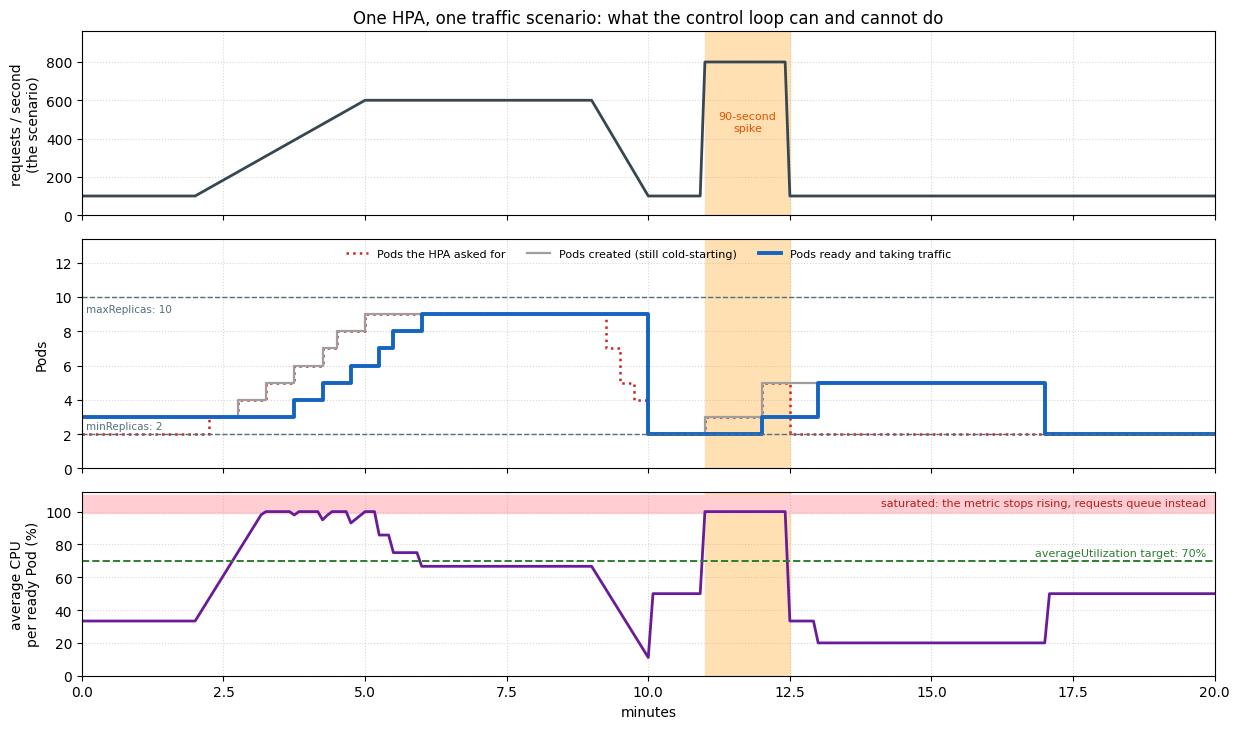

assumptions: one Pod serves 100 req/s at 100% CPU; a new Pod takes 60s to become ready.
Kubernetes defaults used: 15s HPA sync, 300s scale-down stabilization.

  min   req/s  asked for  created  ready   CPU %
    0     100          2        3      3      33
    1     100          2        3      3      33
    2     100          2        3      3      33
    3     267          4        4      3      89
    4     433          6        6      4     100
    5     600          9        9      6     100
    6     600          9        9      9      67
    7     600          9        9      9      67
    8     600          9        9      9      67
    9     600          9        9      9      67
   10     100          2        2      2      11
   11     800          3        3      2     100
   12     800          5        5      3     100
   13     100          2        5      5      20
   14     100          2        5      5      20
   15     100          2        5      5      20
   16  

In [5]:
# WHAT: run the HPA's own control loop over a 20-minute traffic scenario, using the
# minReplicas / maxReplicas / averageUtilization read straight back out of the YAML
# written above, and draw demand, Pods and CPU on one shared time axis.
# WHY: the bullet list says "CPU > 70% -> add Pods". That hides the only thing that
# matters in practice: a Pod that is requested now starts serving MINUTES from now.
# The lag is the lesson, and a lag is a shape over time - it cannot be printed as a rule.
import math
import re

import matplotlib.pyplot as plt

# --- The policy, parsed back out of hpa.yaml so the figure can never drift from it ---
MIN_R = int(re.search(r"minReplicas:\s*(\d+)", hpa_yaml).group(1))
MAX_R = int(re.search(r"maxReplicas:\s*(\d+)", hpa_yaml).group(1))
TARGET = int(re.search(r"averageUtilization:\s*(\d+)", hpa_yaml).group(1)) / 100
START_REPLICAS = int(re.search(r"replicas:\s*(\d+)", deployment_yaml).group(1))

# --- Kubernetes defaults and one stated assumption about OUR container --------------
SYNC_S = 15            # HPA evaluation period (kube-controller-manager default)
STABILIZE_S = 300      # scale-DOWN stabilization window (the 5-minute cooldown, default)
COLD_START_S = 60      # ASSUMED: image pull + container start + model load + readiness probe
POD_CAPACITY = 100     # ASSUMED: requests/second one Pod serves at 100% CPU

DT, HORIZON = 5, 1200  # simulate 20 minutes in 5-second ticks


def offered_load(t):
    """A scenario, not a measurement: a slow ramp, a plateau, then a short sharp spike."""
    if t < 120:  return 100.0
    if t < 300:  return 100.0 + 500.0 * (t - 120) / 180.0     # 3-minute ramp to 600 req/s
    if t < 540:  return 600.0                                  # 4-minute plateau
    if t < 600:  return 600.0 - 500.0 * (t - 540) / 60.0       # traffic falls away
    if t < 660:  return 100.0
    if t < 750:  return 800.0                                  # a 90-SECOND spike
    return 100.0


ts, load_s, ready_s, exist_s, want_s, cpu_s = [], [], [], [], [], []
ready, pending, want, last_scale_up = START_REPLICAS, [], START_REPLICAS, 0

for t in range(0, HORIZON + 1, DT):
    load = offered_load(t)
    # A Pod cannot exceed 100% CPU. Past that, requests queue - the metric saturates
    # and stops telling the HPA how far behind it really is.
    cpu = min(1.0, load / (ready * POD_CAPACITY))

    if t % SYNC_S == 0:                       # the control loop ticks
        # The real HPA formula: desiredReplicas = ceil(readyReplicas * currentMetric / target)
        want = max(MIN_R, min(MAX_R, math.ceil(ready * cpu / TARGET)))
        if want > ready + len(pending):        # scale UP: create Pods, they are NOT ready yet
            pending += [t + COLD_START_S] * (want - ready - len(pending))
            last_scale_up = t
        elif want < ready + len(pending) and t >= last_scale_up + STABILIZE_S:
            drop = ready + len(pending) - want  # scale DOWN, only after the cooldown
            while drop and pending:
                pending.pop()
                drop -= 1
            ready = max(MIN_R, ready - drop)

    ts.append(t / 60)                          # plot in minutes
    load_s.append(load); ready_s.append(ready)
    exist_s.append(ready + len(pending)); want_s.append(want); cpu_s.append(cpu * 100)

    arrived = [r for r in pending if r <= t + DT]   # cold start finished: traffic may now arrive
    pending = [r for r in pending if r > t + DT]
    ready += len(arrived)

SPIKE = (660 / 60, 750 / 60)
fig, axes = plt.subplots(3, 1, figsize=(12.5, 7.4), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.25, 1]})

ax = axes[0]
ax.axvspan(*SPIKE, color="#ffe0b2")
ax.plot(ts, load_s, color="#37474f", lw=2)
ax.text(sum(SPIKE) / 2, max(load_s) * 0.55, "90-second\nspike", ha="center", fontsize=8,
        color="#e65100")
ax.set_ylabel("requests / second\n(the scenario)")
ax.set_ylim(0, max(load_s) * 1.2)
ax.set_title("One HPA, one traffic scenario: what the control loop can and cannot do",
             fontsize=12)
ax.grid(ls=":", alpha=0.5)

ax = axes[1]
ax.axvspan(*SPIKE, color="#ffe0b2")
ax.step(ts, want_s, where="post", color="#c62828", ls=":", lw=1.8,
        label="Pods the HPA asked for")
ax.step(ts, exist_s, where="post", color="#9e9e9e", lw=1.6,
        label="Pods created (still cold-starting)")
ax.step(ts, ready_s, where="post", color="#1565c0", lw=2.8,
        label="Pods ready and taking traffic")
ax.axhline(MIN_R, color="#546e7a", ls="--", lw=1)
ax.text(0.08, MIN_R + 0.30, f"minReplicas: {MIN_R}", fontsize=7.5, color="#546e7a",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
ax.axhline(MAX_R, color="#546e7a", ls="--", lw=1)
ax.text(0.08, MAX_R - 0.85, f"maxReplicas: {MAX_R}", fontsize=7.5, color="#546e7a",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
ax.set_ylabel("Pods")
ax.set_ylim(0, MAX_R + 3.4)
ax.legend(fontsize=8, loc="upper center", ncol=3, frameon=False)
ax.grid(ls=":", alpha=0.5)

ax = axes[2]
ax.axvspan(*SPIKE, color="#ffe0b2")
ax.axhspan(99, 110, color="#ffcdd2")
ax.plot(ts, cpu_s, color="#6a1b9a", lw=2)
ax.axhline(TARGET * 100, color="#2e7d32", ls="--", lw=1.4)
ax.text(HORIZON / 60 - 0.15, TARGET * 100 + 3, f"averageUtilization target: {TARGET:.0%}",
        fontsize=8, color="#2e7d32", ha="right")
ax.text(HORIZON / 60 - 0.15, 105, "saturated: the metric stops rising, requests queue instead",
        fontsize=8, color="#b71c1c", va="center", ha="right")
ax.set_ylim(0, 112)
ax.set_ylabel("average CPU\nper ready Pod (%)")
ax.set_xlabel("minutes")
ax.set_xlim(0, HORIZON / 60)
ax.grid(ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

# The same run as a step table, sampled every minute, so the figure is never the only record.
print(f"assumptions: one Pod serves {POD_CAPACITY} req/s at 100% CPU; a new Pod takes "
      f"{COLD_START_S}s to become ready.\nKubernetes defaults used: {SYNC_S}s HPA sync, "
      f"{STABILIZE_S}s scale-down stabilization.\n")
print(f"{'min':>5} {'req/s':>7} {'asked for':>10} {'created':>8} {'ready':>6} {'CPU %':>7}")
for i in range(0, len(ts), 60 // DT):
    print(f"{ts[i]:>5.0f} {load_s[i]:>7.0f} {want_s[i]:>10} {exist_s[i]:>8} "
          f"{ready_s[i]:>6} {cpu_s[i]:>7.0f}")

spike_idx = [i for i, t in enumerate(ts) if SPIKE[0] <= t <= SPIKE[1]]
saturated = sum(1 for i in range(len(ts)) if cpu_s[i] >= 99) * DT
print(f"\nDuring the 90-second spike the ready-Pod count went "
      f"{ready_s[spike_idx[0]]} -> {ready_s[spike_idx[-1]]}, and CPU stayed at 100% for all of it.")
print(f"CPU sat at 100% for {saturated}s of the {HORIZON}s run - every second of that is "
      f"requests queueing behind\na scale-up that had already been requested.")
peak_after = max(ready_s[i] for i, t in enumerate(ts) if t > SPIKE[1])
print(f"Peak ready Pods AFTER the spike ended: {peak_after} - capacity that arrived for traffic "
      f"that had already gone.")


**Reading the figure.** Three panels, one shared clock. The top panel is the traffic the service
is offered, the middle is what the HPA does about it, and the bottom is the signal it is
reacting to. Read it left to right and four separate things become visible that the bullet list
above cannot say.

**The loop works.** Through the ramp and the plateau, the HPA converges on a Pod count that
holds average CPU just under the green target line, without anyone being paged. That is the
feature, and it is real.

**But it is always late.** The red dotted line is what the HPA *asked for*; the grey line is Pods
that now exist; the thick blue line is Pods that are actually taking traffic. The gap between
red and blue is the cold start — image pull, container start, model load, readiness probe — and
during the ramp it is wide enough to pin CPU in the red saturation band — the printed summary
adds those stretches up to 180 seconds of the run spent at 100% CPU. Note the
mechanism that makes it worse: once CPU saturates at 100%, the metric stops rising, so the
HPA's own formula can only ever ask for about 1.43× the current Pods per evaluation. **A
saturated service cannot tell its autoscaler how far behind it is.**

**The spike is simply missed.** In the orange band, demand jumps eightfold for ninety seconds.
The HPA notices immediately and asks for Pods — but the thick blue line only climbs from two
Pods to three before the spike is over, and the fourth and fifth arrive *after* it, for traffic that
has already gone. Almost the whole spike was absorbed by the two Pods that were already
running, which is why the bottom panel stays pinned at 100% across the entire orange band.
This is the concrete version of "scaling handles demand variation, not instantaneous demand" —
and it is why a burst is handled with headroom or a queue, never with an HPA.

**And you keep paying afterwards.** After the spike the Pods stay up, far below target CPU,
until the 5-minute scale-down stabilization window expires. That cooldown exists to stop
flapping, and its price is the flat over-provisioned stretch on the right of the middle panel.

One honesty note, the same one that applies to the rolling-update storyboard: this is the
policy's own arithmetic — the real HPA formula, the real 15-second sync and 5-minute
stabilization defaults, and `minReplicas`/`maxReplicas`/`averageUtilization` parsed straight back
out of the YAML above — run against a **declared traffic scenario and two stated assumptions**
(a Pod serves 100 req/s at full CPU; a Pod takes 60 s to become ready). It is not a measurement
of a cluster. Change the cold start to the 4 minutes a large model really takes and the middle
panel's blue line falls further behind everything else on the page.


## 6. Key kubectl Commands

Run these in a terminal connected to your cluster (after `kubectl config use-context <cluster>`).

In [6]:
# WHAT: the day-2 operations cheat sheet — the kubectl commands you actually run,
# with example output for each.
# WHY: deploy, inspect, watch autoscaling, roll out, roll back — reading the
# expected output now makes the real terminal much less mysterious later.
kubectl_commands = """
# --- Deploy everything ---
kubectl apply -f deployment.yaml
kubectl apply -f service.yaml
kubectl apply -f hpa.yaml

# --- Check Pod status ---
kubectl get pods
# NAME                              READY   STATUS    RESTARTS   AGE
# iris-classifier-7d9f6b8c4-4xqzp   1/1     Running   0          2m
# iris-classifier-7d9f6b8c4-k9v2d   1/1     Running   0          2m
# iris-classifier-7d9f6b8c4-rj3tf   1/1     Running   0          2m

# --- See the external IP for the Service ---
kubectl get service iris-classifier-svc
# NAME                    TYPE           CLUSTER-IP     EXTERNAL-IP     PORT(S)        AGE
# iris-classifier-svc     LoadBalancer   10.96.142.55   34.117.12.200   80:32100/TCP   3m

# --- Tail logs from one Pod ---
kubectl logs -f iris-classifier-7d9f6b8c4-4xqzp

# --- Watch the HPA scaling decisions ---
kubectl get hpa iris-classifier-hpa --watch
# NAME                   REFERENCE                      TARGETS   MINPODS   MAXPODS   REPLICAS
# iris-classifier-hpa    Deployment/iris-classifier     42%/70%   2         10        3

# --- Manual scale override ---
kubectl scale deployment iris-classifier --replicas=5

# --- Check rollout status after updating the image ---
kubectl rollout status deployment/iris-classifier
# Waiting for rollout to finish: 1 out of 3 new replicas have been updated...
# Waiting for rollout to finish: 2 out of 3 new replicas have been updated...
# deployment "iris-classifier" successfully rolled out

# --- Roll back if the new version is broken ---
kubectl rollout undo deployment/iris-classifier
"""

print(kubectl_commands)


# --- Deploy everything ---
kubectl apply -f deployment.yaml
kubectl apply -f service.yaml
kubectl apply -f hpa.yaml

# --- Check Pod status ---
kubectl get pods
# NAME                              READY   STATUS    RESTARTS   AGE
# iris-classifier-7d9f6b8c4-4xqzp   1/1     Running   0          2m
# iris-classifier-7d9f6b8c4-k9v2d   1/1     Running   0          2m
# iris-classifier-7d9f6b8c4-rj3tf   1/1     Running   0          2m

# --- See the external IP for the Service ---
kubectl get service iris-classifier-svc
# NAME                    TYPE           CLUSTER-IP     EXTERNAL-IP     PORT(S)        AGE
# iris-classifier-svc     LoadBalancer   10.96.142.55   34.117.12.200   80:32100/TCP   3m

# --- Tail logs from one Pod ---
kubectl logs -f iris-classifier-7d9f6b8c4-4xqzp

# --- Watch the HPA scaling decisions ---
kubectl get hpa iris-classifier-hpa --watch
# NAME                   REFERENCE                      TARGETS   MINPODS   MAXPODS   REPLICAS
# iris-classifier-hpa    Deploym

## 7. Rolling Update — Zero-Downtime Deployments

When you update the image tag in the Deployment YAML (e.g., `iris-classifier:v2` → `iris-classifier:v3`), K8s performs a rolling update:
1. Starts 1 new Pod with the new image (`maxSurge: 1` → temporarily 4 Pods exist)
2. Waits until the new Pod passes its readinessProbe
3. Terminates 1 old Pod (back to 3 total, but now 1 old + 2 new)
4. Repeats until all 3 are running the new version

Because `maxUnavailable: 0`, traffic is never sent to fewer than 3 ready Pods. Users never see downtime.

In [7]:
# WHAT: simulate the rolling-update timeline step by step as a printed table.
# WHY: maxSurge=1 with maxUnavailable=0 means capacity never dips below 3 ready
# Pods — this table is the proof that updates can drop zero requests.
# Visualize the rolling update timeline
import time

print("Rolling update timeline (replicas=3, maxSurge=1, maxUnavailable=0):")
print()
print(f"{'Step':<6} {'Old Pods':^12} {'New Pods':^12} {'Total':^8} {'Traffic goes to'}")
print("-" * 62)

# Each tuple is one moment: (step, old pods, new pods, where traffic goes).
steps = [
    ("0",  3, 0, "old pods only"),
    ("1",  3, 1, "old pods only (new pod not ready yet)"),
    ("2",  2, 1, "2 old + 1 new (new pod passed readiness)"),
    ("3",  2, 2, "2 old + 2 new"),
    ("4",  1, 2, "1 old + 2 new"),
    ("5",  1, 3, "1 old + 3 new"),
    ("6",  0, 3, "new pods only"),
]

for step, old, new, note in steps:
    total = old + new
    print(f"{step:<6} {old:^12} {new:^12} {total:^8} {note}")

print()
print("At every step, at least 3 ready Pods serve traffic.")
print("Zero requests are dropped during the entire update.")

Rolling update timeline (replicas=3, maxSurge=1, maxUnavailable=0):

Step     Old Pods     New Pods    Total   Traffic goes to
--------------------------------------------------------------
0           3            0          3     old pods only
1           3            1          4     old pods only (new pod not ready yet)
2           2            1          3     2 old + 1 new (new pod passed readiness)
3           2            2          4     2 old + 2 new
4           1            2          3     1 old + 2 new
5           1            3          4     1 old + 3 new
6           0            3          3     new pods only

At every step, at least 3 ready Pods serve traffic.
Zero requests are dropped during the entire update.


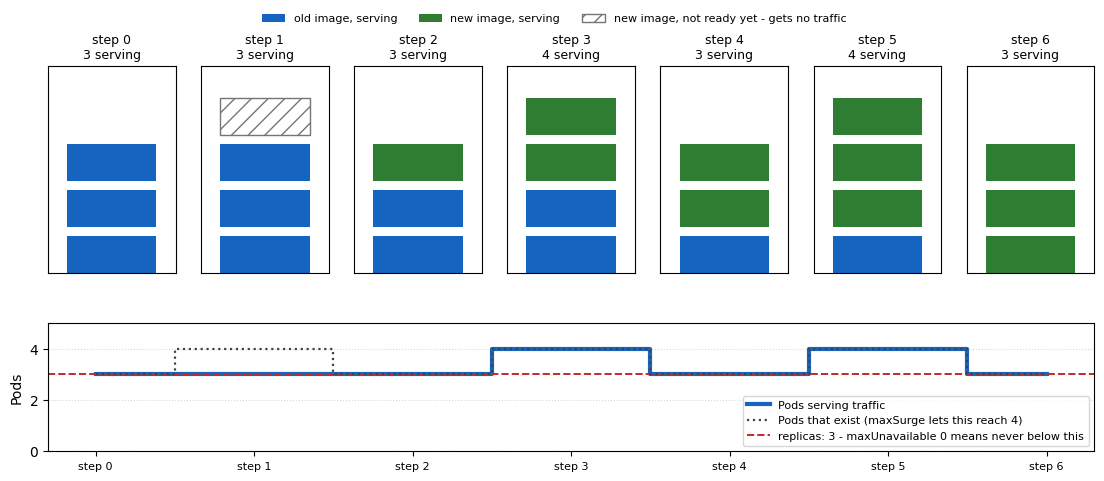

step   serving   exist   spare capacity above replicas=3
0      3         3       +0
1      3         4       +0
2      3         3       +0
3      4         4       +1
4      3         3       +0
5      4         4       +1
6      3         3       +0

lowest number of Pods serving at any step: 3 (required: 3)


In [8]:
# WHAT: turn the rolling-update table printed above into a storyboard - one frame per
# step showing the actual Pods, and one strip underneath tracking serving capacity.
# WHY: "zero downtime" is a claim about a QUANTITY THAT NEVER DIPS. A table of numbers
# asks you to verify that in your head; the capacity line under the frames shows it.
# Note this is the timeline the manifest DECLARES (replicas 3, maxSurge 1,
# maxUnavailable 0) - it is a reading of the policy, not a measurement of a cluster.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

DESIRED = 3        # spec.replicas in deployment.yaml
frames = []
for step, old, new, note in steps:
    not_ready = 1 if "not ready" in note else 0      # the note above says which Pod is still starting
    frames.append((step, old, new - not_ready, not_ready))
ready = [old + new_ready for _s, old, new_ready, _nr in frames]
total = [old + new_ready + nr for _s, old, new_ready, nr in frames]

fig = plt.figure(figsize=(13.5, 5.0))
gs = fig.add_gridspec(2, len(frames), height_ratios=[2.1, 1.3], hspace=0.30)

for i, (step, old, new_ready, not_ready) in enumerate(frames):
    ax = fig.add_subplot(gs[0, i])
    y = 0
    for _ in range(old):                    # Pods still running the old image
        ax.add_patch(Rectangle((0.15, y), 0.7, 0.8, facecolor="#1565c0"))
        y += 1
    for _ in range(new_ready):              # new image, readinessProbe passed -> serving
        ax.add_patch(Rectangle((0.15, y), 0.7, 0.8, facecolor="#2e7d32"))
        y += 1
    for _ in range(not_ready):              # new image, still starting -> no traffic
        ax.add_patch(Rectangle((0.15, y), 0.7, 0.8, facecolor="white",
                               edgecolor="#757575", hatch="//"))
        y += 1
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 4.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"step {step}\n{old + new_ready} serving", fontsize=9)

fig.legend(handles=[Patch(facecolor="#1565c0", label="old image, serving"),
                    Patch(facecolor="#2e7d32", label="new image, serving"),
                    Patch(facecolor="white", edgecolor="#757575", hatch="//",
                          label="new image, not ready yet - gets no traffic")],
           loc="upper center", ncol=3, fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.005))

ax = fig.add_subplot(gs[1, :])
ax.step(range(len(frames)), ready, where="mid", color="#1565c0", lw=3,
        label="Pods serving traffic")
# drawn last, on top, so it stays visible where it coincides with the blue line
ax.step(range(len(frames)), total, where="mid", color="#424242", ls=":", lw=1.6,
        zorder=4, label="Pods that exist (maxSurge lets this reach 4)")
ax.axhline(DESIRED, color="#c62828", ls="--", lw=1.4,
           label=f"replicas: {DESIRED} - maxUnavailable 0 means never below this")
ax.set_ylim(0, 5)
ax.set_xticks(range(len(frames)))
ax.set_xticklabels([f"step {s}" for s, _o, _n, _nr in frames], fontsize=8)
ax.set_ylabel("Pods")
ax.legend(fontsize=8, loc="lower right", ncol=1)
ax.grid(axis="y", ls=":", alpha=0.5)

plt.show()

# The storyboard as numbers, matching the table printed in the cell above.
print(f"{'step':<6} {'serving':<9} {'exist':<7} spare capacity above replicas={DESIRED}")
for (step, old, new_ready, nr), r, t in zip(frames, ready, total):
    print(f"{step:<6} {r:<9} {t:<7} {r - DESIRED:+d}")
print(f"\nlowest number of Pods serving at any step: {min(ready)} (required: {DESIRED})")


**Reading the storyboard.** Seven frames, one per step of the rollout the manifest describes.
Blue blocks are Pods on the old image, green blocks are Pods on the new image that have
passed their readiness probe, and the hatched block at step 1 is the new Pod that exists but
is **not** receiving traffic yet — the readiness probe is what keeps requests away from a
process that is still loading its model.

The strip underneath is the claim itself. The dotted line counts Pods that *exist*, and it lifts
to 4 at every step where `maxSurge: 1` allows an extra one during a swap. The thick blue line
counts Pods actually *serving*, and it never falls below the red line: it rides along it at the
steps where exactly three Pods serve, and rises above it during each swap, because
`maxUnavailable: 0` forbids taking an old Pod down before its replacement is ready. **The
rollout costs you a fourth Pod's worth of resources for part of the time, and buys a serving
capacity that never dips.** That is the trade the "💬 Discuss" question below asks you to price.

One honesty note: this is a drawing of the policy those YAML fields declare, computed from
the same table the previous cell printed — not a measurement of a live cluster. On a real
cluster the guarantee holds only if the readiness probe genuinely reports readiness, which is
exactly what question 2 below is about.

## 💬 Discuss

The rolling-update table above is the experiment: with `replicas: 3`, `maxSurge: 1`, `maxUnavailable: 0`, the printed timeline never drops below 3 ready Pods at any step. That is the guarantee. Argue about its price and its edges.

1. `maxUnavailable: 0` guarantees no capacity loss and makes every rollout slower and briefly more expensive (4 Pods instead of 3). For a model API serving internal dashboards at 09:00, would you keep it? What would you change for a service where a 30-second gap is genuinely acceptable?
2. Traffic reaches a Pod only after `/health` returns 200. Our `/health` returns `{"status": "ok"}` as soon as the process starts. If loading the model takes 40 seconds, what does the readiness probe actually certify — and what would a caller experience during a rollout? Write the probe you would use instead.
3. The HPA scales on CPU at 70%. For a model whose latency is dominated by waiting on a feature store, CPU stays low while requests queue. Name the metric you would scale on instead, and say what new failure mode you have just introduced by scaling on it.

## 8. Writing All Manifests to Disk

In [9]:
# Verify all three YAML files were written
import os
for fname in os.listdir(YAML_DIR):
    path = os.path.join(YAML_DIR, fname)
    size = os.path.getsize(path)
    print(f"{fname}: {size} bytes")

print(f"\nApply all with: kubectl apply -f {YAML_DIR}/")
print("K8s will create the Deployment, Service, and HPA in that order.")

deployment.yaml: 1511 bytes
service.yaml: 458 bytes
hpa.yaml: 675 bytes

Apply all with: kubectl apply -f /tmp/k8s_manifests/
K8s will create the Deployment, Service, and HPA in that order.


## 9. K8s vs Plain Docker

| Capability | Plain Docker | Kubernetes |
|---|---|---|
| Run 1 container | Yes | Yes |
| Auto-restart on crash | No (need docker restart policy) | Yes (always) |
| Load balance across replicas | No (need nginx/haproxy) | Yes (Service) |
| Auto-scale on CPU | No | Yes (HPA) |
| Zero-downtime update | No | Yes (rolling update) |
| Multi-node scheduling | No | Yes |
| Health-gate traffic | No | Yes (readinessProbe) |

## 10. Summary

In this notebook you:
- Learned the four core K8s objects: Pod, Deployment, Service, HPA
- Wrote a Deployment YAML with resource limits, readiness probes, and a rolling update strategy
- Wrote a LoadBalancer Service YAML that routes port 80 to container port 8000
- Wrote an HPA YAML that scales 2-10 replicas at 70% CPU target
- Traced through a rolling update showing zero Pods are unavailable at any step

**K8s in one sentence:** you declare what you want; K8s continuously makes the cluster match your declaration, handling failures and scaling automatically.

## Self-Check (answer before scrolling up)

1. **What is the difference between a Pod and a Deployment?** Why do you almost never create Pods directly?
2. **What does the HPA do when CPU drops below 70% for an extended period?** Is this instant? Why or why not?
3. **What is a rolling update and why is it better than stopping all replicas before starting new ones?** Which YAML field guarantees no Pod is taken down before a replacement is ready?

## ⚠️ Where this breaks

- **The HPA cannot conjure capacity.** It changes a replica count. If the cluster has no room, Pods sit `Pending`; if the cloud region cannot launch instances — as in `us-east-1` on 20 October 2025 — nothing helps. Autoscaling handles *demand* variation, not *supply* failure. Multi-region is the answer to supply failure, and it is a different, much more expensive design.
- **CPU is usually the wrong scaling signal for model serving.** It is the default because it is always available. If your service is I/O-bound, or if inference is fast but queueing is slow, CPU utilisation stays flat while p99 latency climbs. Scale on requests-per-Pod or on queue depth when you can measure them.
- **Scaling is not instant, and cold starts are the hidden cost.** Between "CPU crosses 70%" and "a new Pod serves traffic" sit: HPA's evaluation interval, scheduling, image pull, container start, model load, and readiness probe. For a large artifact that is minutes. A traffic spike that lasts 90 seconds will be over before the extra Pods arrive.
- **The assumption that must hold:** Pods are stateless and interchangeable. Anything a replica keeps in memory — a cache, a rate-limit counter, an in-process log buffer — is per-Pod and disappears on every scale-down and every rollout. The in-memory rate limiter from Unit 3 notebook 05 is a concrete example that breaks the moment you run more than one replica.
- **Readiness probes only certify what they check.** A probe that returns 200 from a process that has not finished loading its model will happily route real traffic into a `503`. Make the probe assert the thing you care about — that the model is loaded and can score the card's sample row.
- **The cheaper alternative.** Kubernetes has a real operational cost: manifests, an upgrade treadmill, and a class of failures your team must learn to debug. For a single model with predictable traffic, one container behind a managed load balancer — or a serverless container platform that scales to zero — is less machinery and fewer ways to be wrong. Adopt Kubernetes when you have several services to orchestrate, not because it is what production is supposed to look like.

## 🔭 State of the field (2026)

Pods, Deployments, Services and rolling updates are unchanged in 2026, and this is still the substrate most ML services run on. The part the field has moved past is the *signal*. A threshold on CPU — the `70` you set above — reacts only after the queue has already formed, which is the limitation the "Where this breaks" section names and which 2026 autoscaling work states directly: threshold-based CPU or memory metrics react too slowly to traffic spikes, and predictive methods that emit a single point forecast ignore its uncertainty and end up either over-provisioning or oscillating ([arXiv 2608.18390](https://arxiv.org/abs/2608.18390)). For model serving specifically the scaling *unit* also grew: rather than a replica count alone, systems now scale serving instances and their batch sizes together, and treat interactive and batch traffic as separate SLO classes sharing the same hardware ([arXiv 2501.08090](https://arxiv.org/abs/2501.08090)).

**Why this lesson is still the right thing to learn.** Every one of those schedulers ends at the same place your HPA does — a desired replica count handed to the Kubernetes API through the objects you wrote here — so the manifest is the interface, whatever computes the number. The cold-start cost, the capacity limit from the October 2025 outage, and the statelessness assumption apply to the clever autoscalers exactly as they apply to this one. Reading and writing a Deployment, a Service and an HPA is what the official plan examines, and it is the prerequisite for understanding any of the newer controllers.

*Orientation only — the assessed content of this lesson is everything above this box.*


## 📚 References

1. Verma, A., Pedrosa, L., Korupolu, M. R., Oppenheimer, D., Tune, E., & Wilkes, J. (2015). *Large-Scale Cluster Management at Google with Borg*. EuroSys. <https://research.google/pubs/large-scale-cluster-management-at-google-with-borg/>
2. Burns, B., Grant, B., Oppenheimer, D., Brewer, E., & Wilkes, J. (2016). *Borg, Omega, and Kubernetes*. ACM Queue 14(1). <https://research.google/pubs/borg-omega-and-kubernetes/>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
4. Patke, A., Reddy, D., Jha, S., Narayanaswami, C., Kalbarczyk, Z., & Iyer, R. (2025). *Hierarchical Autoscaling for Large Language Model Serving with Chiron*. arXiv. <https://arxiv.org/abs/2501.08090> — autoscaling a workload that mixes interactive requests (SLOs in seconds) with batch requests (SLOs in minutes to hours), where the scaling decision covers serving instances *and* their batch sizes rather than a replica count alone.
5. Wang, S., Sun, X., Huang, S., Su, B., Xu, S., & Awate, N. (2026). *SLO-Scaler: Uncertainty-Aware SLO-Driven Autoscaling for Microservices*. arXiv. <https://arxiv.org/abs/2608.18390> — states the limitation of the HPA you wrote above in its own abstract: threshold-based CPU or memory metrics react too slowly to traffic spikes, and predictive methods that emit a single point forecast ignore its uncertainty and end up over-provisioning or oscillating. Evaluated on Kubernetes under periodic, bursty and long-tail traffic.
